# Standard / Reference Material Detection Demo

**Datamine CCLAS QC Anomaly Detection**

This notebook demonstrates the current SRMS/reference-material detection workflow for Standard records extracted from a CCLAS LabBatch TSV.

The current dataset identifies these records as Standard/STD. There is no separate field in the supplied TSV that independently confirms an SRMS subtype, so they are treated as Standard/reference-material candidates for this component.


## Detection Scope

**Included:** STD / Standard records.

**Excluded:** BLK, SPK, REP, DUP, MSD, and UNK records.

The notebook calls the production detector in `src.detectors.srms_detector`; it does not duplicate the detector implementation.


## Detection Architecture

```text
CCLAS LabBatch TSV
      ↓
Extract STD Records
      ↓
Known Acceptance Limits
      ↓
Historical Comparison
      ↓
Isolation Forest + Drift
      ↓
Final Risk
      ↓
Explanation / Validation
```

Known QC acceptance limits take priority over machine learning. A hard known-limit failure remains Critical regardless of historical or Isolation Forest signals.


## Setup

The data and configuration paths are defined once near the beginning of the notebook. Thresholds are loaded from YAML rather than hard-coded in notebook logic.


In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src" / "detectors" / "srms_detector.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.detectors import srms_detector as srms

CURRENT_TSV = PROJECT_ROOT / "data" / "TSV_LB26019534_I_0024367023.TSV"
HISTORY_WORKBOOK = PROJECT_ROOT / "data" / "QC Anomaly Training Data v3.xlsx"
if not HISTORY_WORKBOOK.exists():
    HISTORY_WORKBOOK = Path.home() / "Downloads" / "QC Anomaly Training Data v3.xlsx"
CONFIG_PATH = PROJECT_ROOT / "config" / "srms_detector.yaml"

for path in [CURRENT_TSV, HISTORY_WORKBOOK, CONFIG_PATH]:
    if not path.exists():
        raise FileNotFoundError(path)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)


## Configuration

The YAML file is the authoritative SRMS configuration. The historical worksheet is loaded from `srms.historical.sheet` unless an explicit command-line override is supplied outside the notebook.


In [2]:
config = srms.load_srms_config(str(CONFIG_PATH))
CONFIG = {
    "historical_sheet": config.historical_sheet,
    "robust_z_threshold": config.robust_z_threshold,
    "strong_robust_z_threshold": config.strong_robust_z_threshold,
    "rolling_window": config.rolling_window,
    "min_history": config.min_history,
    "iforest_min_history": config.min_iforest_history,
    "iforest_contamination": config.contamination,
    "iforest_n_estimators": config.n_estimators,
    "iforest_random_state": config.random_state,
    "drift_min_history": config.min_drift_history,
    "drift_slope_pct_threshold": config.drift_slope_pct_threshold,
    "drift_mean_shift_pct_threshold": config.drift_mean_shift_pct_threshold,
    "drift_consecutive_points": config.drift_consecutive_points,
}
config_table = pd.DataFrame(CONFIG.items(), columns=["Setting", "Value"])
display(config_table)
assert config.historical_sheet == "GO_FAA50V10 Asssessment"


,Setting,Value
0,historical_sheet,GO_FAA50V10 Asssessment
1,robust_z_threshold,3.5
2,strong_robust_z_threshold,4.5
3,rolling_window,5
4,min_history,5
5,iforest_min_history,20
6,iforest_contamination,0.05
7,iforest_n_estimators,250
8,iforest_random_state,42
9,drift_min_history,5


## Parse CCLAS LabBatch

The production parser converts the sequential `OBJECT / PROPERTY / VALUE` TSV into result rows, then extracts only Standard records.


In [3]:
parsed = srms.parse_cclas_tsv(CURRENT_TSV)
std_records = srms.extract_cclas_standard_records(parsed)

qc_distribution = parsed.get("QCType", pd.Series(dtype=object)).fillna("<missing>").value_counts().rename_axis("QCType").reset_index(name="Rows")
display(qc_distribution)

std_columns = [
    "SampleCode", "StandardCode", "Scheme", "Analyte", "Result", "Target",
    "LowerLimit", "LowerWarning", "UpperWarning", "UpperLimit", "CCLAS_StandardStatus",
]
display(std_records[std_columns])
assert len(std_records) == 4


,QCType,Rows
0,UNKNOWN,17
1,SPIKE,8
2,REPEAT,8
3,STD,4
4,REP,3
5,BLK,2
6,DUP,1


,SampleCode,StandardCode,Scheme,Analyte,Result,Target,LowerLimit,LowerWarning,UpperWarning,UpperLimit,CCLAS_StandardStatus
0,TSV_S0024366455,OXE113,GO_FAA50V10,AU,0.60,0.609,0.52307,0.554495,0.663505,0.69493,PASS
1,TSV_S0024366457,AUOP_06,GO_FAA50V10,AU,1.00,5.691,5.09686,5.314256,6.067744,6.28514,LOWER_FAILURE
2,TSV_S0024366460,OXE113,GO_FAA50V10,AU,0.06,0.609,0.52307,0.554495,0.663505,0.69493,LOWER_FAILURE
3,TSV_S0024366462,AUOP_06,GO_FAA50V10,AU,0.40,5.691,5.09686,5.314256,6.067744,6.28514,LOWER_FAILURE


## Historical Dataset

Historical data comes from `QC Anomaly Training Data v3.xlsx`, worksheet `GO_FAA50V10 Asssessment`, and is matched to current records by Standard + Scheme + Analyte.


In [4]:
raw_history = srms.load_data(HISTORY_WORKBOOK, sheet_name=config.historical_sheet)
historical = srms.prepare_historical_srms_baseline(HISTORY_WORKBOOK, config, sheet_name=config.historical_sheet)

history_summary = pd.DataFrame([
    [len(raw_history), raw_history["STD_CODE"].nunique(), raw_history["SCHEME_CODE"].nunique(), raw_history["ANALYTE_CODE"].nunique(), raw_history["ANALYSED_DATE"].min(), raw_history["ANALYSED_DATE"].max()]
], columns=["Rows", "Unique Standards", "Unique Schemes", "Unique Analytes", "FirstDate", "LastDate"])
display(history_summary)

current_groups = std_records[["StandardCode", "Scheme", "Analyte"]].drop_duplicates()
coverage_rows = []
for row in current_groups.itertuples(index=False):
    mask = (
        raw_history["STD_CODE"].astype(str).eq(str(row.StandardCode))
        & raw_history["SCHEME_CODE"].astype(str).eq(str(row.Scheme))
        & raw_history["ANALYTE_CODE"].astype(str).eq(str(row.Analyte))
    )
    group = raw_history.loc[mask]
    coverage_rows.append({
        "StandardCode": row.StandardCode,
        "Scheme": row.Scheme,
        "Analyte": row.Analyte,
        "HistoryCount": len(group),
        "FirstDate": group["ANALYSED_DATE"].min(),
        "LastDate": group["ANALYSED_DATE"].max(),
    })
coverage = pd.DataFrame(coverage_rows)
display(coverage)
assert dict(zip(coverage["StandardCode"], coverage["HistoryCount"])) == {"OXE113": 301, "AUOP_06": 622}

duplicate_subset = ["STD_CODE", "SCHEME_CODE", "ANALYTE_CODE", "JOB_CODE", "NUMERIC_FINAL_VALUE", "ANALYSED_DATE"]
duplicate_rows = []
for row in current_groups.itertuples(index=False):
    mask = (
        raw_history["STD_CODE"].astype(str).eq(str(row.StandardCode))
        & raw_history["SCHEME_CODE"].astype(str).eq(str(row.Scheme))
        & raw_history["ANALYTE_CODE"].astype(str).eq(str(row.Analyte))
    )
    group = raw_history.loc[mask]
    dup_mask = group.duplicated(subset=duplicate_subset, keep=False)
    duplicate_rows.append({
        "StandardCode": row.StandardCode,
        "DuplicateRows": int(dup_mask.sum()),
        "DuplicateGroups": int(group.loc[dup_mask, duplicate_subset].drop_duplicates().shape[0]),
    })
duplicate_note = pd.DataFrame(duplicate_rows)
display(duplicate_note)


,Rows,Unique Standards,Unique Schemes,Unique Analytes,FirstDate,LastDate
0,32079,64,1,2,2018-04-16 16:50:16,2025-11-26 10:38:42


,StandardCode,Scheme,Analyte,HistoryCount,FirstDate,LastDate
0,OXE113,GO_FAA50V10,AU,301,2018-05-03 09:08:43,2025-11-26 10:38:42
1,AUOP_06,GO_FAA50V10,AU,622,2019-05-27 14:08:51,2022-09-06 13:40:31


,StandardCode,DuplicateRows,DuplicateGroups
0,OXE113,6,3
1,AUOP_06,0,0


**Data Quality Note**

Six exact duplicate historical rows were identified for OXE113, forming three duplicate groups. These records are retained because they are present in the client-provided historical source and no deduplication rule has yet been confirmed by Datamine.


## Run Production Detector

The next cell runs the full Standard/reference-material pipeline from `src.detectors.srms_detector` using the current TSV and the GO historical worksheet.


In [5]:
results, status_summary, risk_summary = srms.run_cclas_standard_pipeline(
    str(CURRENT_TSV),
    config,
    history_path=str(HISTORY_WORKBOOK),
    sheet_name=config.historical_sheet,
)
results = srms.order_cclas_standard_columns(results)

display(status_summary.sort_values("Limit_Status"))
display(risk_summary.sort_values("Final_Risk"))


,Limit_Status,Count
0,FAIL,3
1,PASS,1


,Final_Risk,Count
0,Critical,3
1,Low,1


## Known Acceptance Limit Assessment

**PASS:** The result is within the acceptance limits and does not breach the warning thresholds.

**WARNING:** The result remains within the hard acceptance limits but breaches a configured warning threshold.

**FAIL:** The result breaches a hard lower or upper acceptance limit.

Configured inclusive/exclusive boundaries are respected by the production detector.


In [6]:
limit_columns = ["SampleCode", "StandardCode", "Result", "LowerLimit", "LowerWarning", "UpperWarning", "UpperLimit", "Limit_Status"]
display(results[limit_columns])
limit_counts = results["Limit_Status"].value_counts().to_dict()
assert limit_counts.get("PASS", 0) == 1
assert limit_counts.get("WARNING", 0) == 0
assert limit_counts.get("FAIL", 0) == 3


,SampleCode,StandardCode,Result,LowerLimit,LowerWarning,UpperWarning,UpperLimit,Limit_Status
0,TSV_S0024366455,OXE113,0.60,0.52307,0.554495,0.663505,0.69493,PASS
1,TSV_S0024366457,AUOP_06,1.00,5.09686,5.314256,6.067744,6.28514,FAIL
2,TSV_S0024366460,OXE113,0.06,0.52307,0.554495,0.663505,0.69493,FAIL
3,TSV_S0024366462,AUOP_06,0.40,5.09686,5.314256,6.067744,6.28514,FAIL


## Historical Comparison

The historical comparison uses Median, MAD, and Robust Z-score for the matching Standard + Scheme + Analyte group.

`Robust Z = 0.6745 × (Current − Median) / MAD`

Only historical observations are used for the baseline. The current TSV rows are not appended into the training or baseline data before scoring.


In [7]:
historical_columns = [
    "SampleCode", "StandardCode", "Result", "HistoryCount", "HistoricalMedian",
    "HistoricalMAD", "RobustZScore", "Historical_Status",
]
display(results[historical_columns])
assert results["HistoryCount"].ge(config.min_history).sum() == 4
assert results["Historical_Status"].eq("INSUFFICIENT_HISTORY").sum() == 0


,SampleCode,StandardCode,Result,HistoryCount,HistoricalMedian,HistoricalMAD,RobustZScore,Historical_Status
0,TSV_S0024366455,OXE113,0.60,301,0.612381,0.010187,-0.819725,PASS
1,TSV_S0024366457,AUOP_06,1.00,622,5.577437,0.121228,-25.468470,WARNING
2,TSV_S0024366460,OXE113,0.06,301,0.612381,0.010187,-36.572914,WARNING
3,TSV_S0024366462,AUOP_06,0.40,622,5.577437,0.121228,-28.806819,WARNING


## Historical Visualisation

Each plot shows the historical distribution over time, configured limits, target, and the current LabBatch result for the matching Standard group.


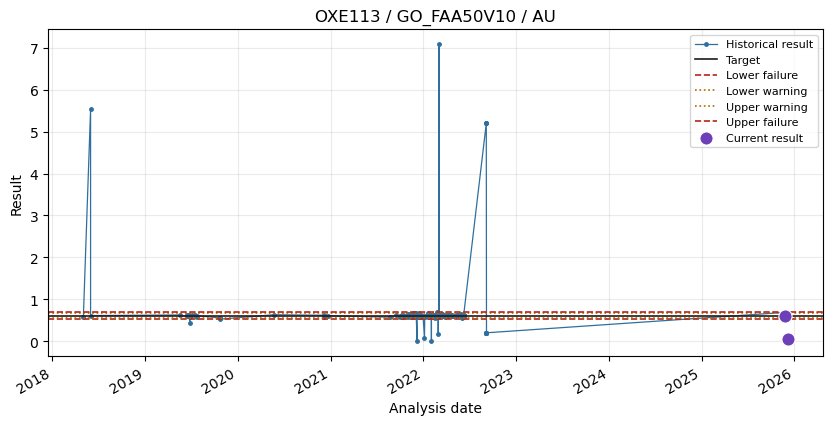

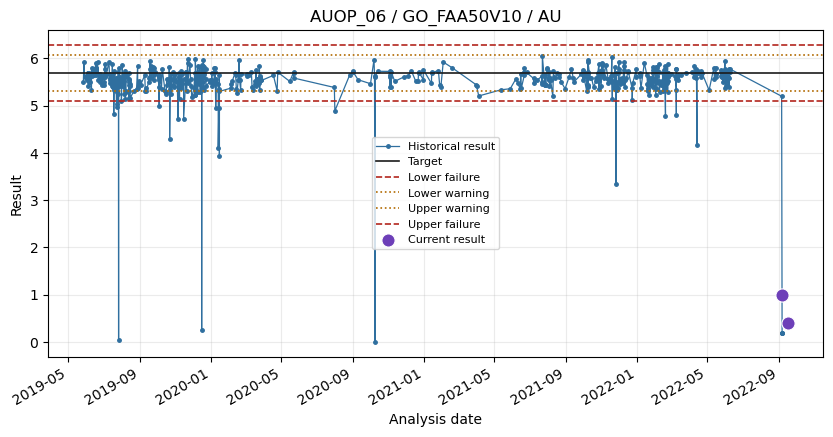

In [8]:
def plot_standard_history(standard_code, scheme, analyte):
    hist_group = historical[
        historical["SRMSStandardCode"].eq(standard_code)
        & historical["SchemeCode"].eq(scheme)
        & historical["Analyte"].eq(analyte)
    ].sort_values("AnalysisDate")
    current_group = results[
        results["StandardCode"].eq(standard_code)
        & results["Scheme"].eq(scheme)
        & results["Analyte"].eq(analyte)
    ]
    fig, ax = plt.subplots(figsize=(10, 4.8))
    ax.plot(hist_group["AnalysisDate"], hist_group["Value"], marker="o", markersize=2.5, linewidth=0.9, color="#2f6f9f", label="Historical result")
    first_current = current_group.iloc[0]
    limit_lines = [
        ("Target", first_current.get("Target"), "#1b1b1b", "-"),
        ("Lower failure", first_current.get("LowerLimit"), "#b3261e", "--"),
        ("Lower warning", first_current.get("LowerWarning"), "#b26a00", ":"),
        ("Upper warning", first_current.get("UpperWarning"), "#b26a00", ":"),
        ("Upper failure", first_current.get("UpperLimit"), "#b3261e", "--"),
    ]
    for label, value, color, style in limit_lines:
        if pd.notna(value):
            ax.axhline(value, color=color, linestyle=style, linewidth=1.2, label=label)
    current_x = hist_group["AnalysisDate"].max()
    if pd.isna(current_x):
        current_x = pd.Timestamp.today()
    for _, row in current_group.iterrows():
        ax.scatter([current_x], [row["Result"]], s=90, color="#6d3fb8", edgecolor="white", linewidth=0.8, zorder=5, label="Current result")
        current_x = current_x + pd.Timedelta(days=10)
    ax.set_title(f"{standard_code} / {scheme} / {analyte}")
    ax.set_xlabel("Analysis date")
    ax.set_ylabel("Result")
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), loc="best", fontsize=8)
    ax.grid(True, alpha=0.25)
    fig.autofmt_xdate()
    plt.show()

for group in current_groups.itertuples(index=False):
    plot_standard_history(group.StandardCode, group.Scheme, group.Analyte)


## Isolation Forest

Isolation Forest provides an additional anomaly signal based on historical behaviour. It does not override known QC limits.


In [9]:
iforest_columns = ["SampleCode", "StandardCode", "IsolationForestScore", "IsolationForestStatus", "IsolationForestAnomaly"]
display(results[iforest_columns])
assert results["IsolationForestStatus"].isin(["PASS", "WARNING"]).sum() == 4
assert int(results["IsolationForestAnomaly"].sum()) == 3


,SampleCode,StandardCode,IsolationForestScore,IsolationForestStatus,IsolationForestAnomaly
0,TSV_S0024366455,OXE113,0.494807,PASS,False
1,TSV_S0024366457,AUOP_06,0.790641,WARNING,True
2,TSV_S0024366460,OXE113,0.779400,WARNING,True
3,TSV_S0024366462,AUOP_06,0.801630,WARNING,True


## Drift Detection

The current extreme failed observations are point anomalies and do not necessarily indicate a sustained historical drift.


In [10]:
drift_columns = ["SampleCode", "StandardCode", "RollingMean", "RollingStd", "RollingSlope", "RollingSlopePctTarget", "DriftFlag"]
display(results[drift_columns])
assert int(results["DriftFlag"].sum()) == 0


,SampleCode,StandardCode,RollingMean,RollingStd,RollingSlope,RollingSlopePctTarget,DriftFlag
0,TSV_S0024366455,OXE113,0.29760,0.218240,0.09760,16.026273,False
1,TSV_S0024366457,AUOP_06,2.31586,2.904491,-1.61586,-28.393250,False
2,TSV_S0024366460,OXE113,0.29760,0.218240,0.09760,16.026273,False
3,TSV_S0024366462,AUOP_06,2.31586,2.904491,-1.61586,-28.393250,False


## Final Risk

| Condition | Final risk |
|---|---|
| Limit FAIL | Critical |
| Limit WARNING + supporting anomaly | High |
| Limit WARNING | Medium |
| Limit PASS + supporting anomaly | Medium |
| Limit PASS | Low |


In [11]:
final_columns = [
    "SampleCode", "StandardCode", "Result", "Limit_Status", "Historical_Status",
    "IsolationForestStatus", "DriftFlag", "Final_Risk", "Detection_Method",
]
display(results[final_columns])
risk_counts = results["Final_Risk"].value_counts().to_dict()
assert risk_counts.get("Low", 0) == 1
assert risk_counts.get("Critical", 0) == 3


,SampleCode,StandardCode,Result,Limit_Status,Historical_Status,IsolationForestStatus,DriftFlag,Final_Risk,Detection_Method
0,TSV_S0024366455,OXE113,0.60,PASS,PASS,PASS,False,Low,Known QC limit rule
1,TSV_S0024366457,AUOP_06,1.00,FAIL,WARNING,WARNING,False,Critical,Known QC limit rule with historical robust z-s...
2,TSV_S0024366460,OXE113,0.06,FAIL,WARNING,WARNING,False,Critical,Known QC limit rule with historical robust z-s...
3,TSV_S0024366462,AUOP_06,0.40,FAIL,WARNING,WARNING,False,Critical,Known QC limit rule with historical robust z-s...


## Explanation

The production detector returns a human-readable reason for each current Standard result. For failed known-limit records, the hard limit failure is the primary reason.


In [12]:
display(results[["SampleCode", "StandardCode", "Final_Risk", "Reason"]])


,SampleCode,StandardCode,Final_Risk,Reason
0,TSV_S0024366455,OXE113,Low,Result is within the configured acceptance and...
1,TSV_S0024366457,AUOP_06,Critical,Result 1 is below the lower acceptance limit 5...
2,TSV_S0024366460,OXE113,Critical,Result 0.06 is below the lower acceptance limi...
3,TSV_S0024366462,AUOP_06,Critical,Result 0.4 is below the lower acceptance limit...


## CCLAS Validation

CCLAS Standard Status is used for validation only. It is not used as a detector input or model feature.


In [13]:
validation_columns = ["SampleCode", "Limit_Status", "CCLAS_StandardStatus", "CCLAS_StandardStatus_Normalized", "CCLAS_Mismatch"]
display(results[validation_columns])
assert int(results["CCLAS_Mismatch"].sum()) == 0


,SampleCode,Limit_Status,CCLAS_StandardStatus,CCLAS_StandardStatus_Normalized,CCLAS_Mismatch
0,TSV_S0024366455,PASS,PASS,PASS,False
1,TSV_S0024366457,FAIL,LOWER_FAILURE,FAIL,False
2,TSV_S0024366460,FAIL,LOWER_FAILURE,FAIL,False
3,TSV_S0024366462,FAIL,LOWER_FAILURE,FAIL,False


## Final Summary

The compact summary below is generated directly from the production detector output.


In [14]:
summary = pd.DataFrame([
    ["Current Standard records", len(results)],
    ["Limit PASS", int(results["Limit_Status"].eq("PASS").sum())],
    ["Limit WARNING", int(results["Limit_Status"].eq("WARNING").sum())],
    ["Limit FAIL", int(results["Limit_Status"].eq("FAIL").sum())],
    ["Historical sufficient", int(results["HistoryCount"].ge(config.min_history).sum())],
    ["Historical insufficient", int(results["HistoryCount"].lt(config.min_history).sum())],
    ["Isolation Forest scored", int(results["IsolationForestStatus"].isin(["PASS", "WARNING"]).sum())],
    ["Isolation Forest anomalies", int(results["IsolationForestAnomaly"].sum())],
    ["Drift flags", int(results["DriftFlag"].sum())],
    ["Risk Low", int(results["Final_Risk"].eq("Low").sum())],
    ["Risk Critical", int(results["Final_Risk"].eq("Critical").sum())],
    ["CCLAS mismatches", int(results["CCLAS_Mismatch"].sum())],
], columns=["Metric", "Value"])
display(summary)


,Metric,Value
0,Current Standard records,4
1,Limit PASS,1
2,Limit WARNING,0
3,Limit FAIL,3
4,Historical sufficient,4
5,Historical insufficient,0
6,Isolation Forest scored,4
7,Isolation Forest anomalies,3
8,Drift flags,0
9,Risk Low,1


## Key Findings

- Known QC acceptance limits correctly identify the three failed Standards.
- Historical comparison provides additional evidence that the failed values are far outside normal historical behaviour.
- Isolation Forest independently flags the same three unusual observations.
- The passing OXE113 result is consistent with its historical distribution.
- No sustained drift is detected in the current examples.
- Final risk remains QC-first and explainable.
- Historical and ML signals do not override known CCLAS acceptance limits.


## Limitations / Items for Datamine Confirmation

1. Current LabBatch data exposes records as Standard/STD; confirmation may be required if Datamine distinguishes a narrower SRMS subtype.
2. Historical matching currently uses Standard + Scheme + Analyte.
3. Six exact duplicate OXE113 historical rows are retained pending confirmation on whether Datamine expects deduplication.
